# 01 · Multiscale microkinetics: from DFT to the reactor

This notebook follows the TMSPA water scavenger in ethylene carbonate (EC) through every scale of the model. It starts from DFT and molecular-dynamics energies of single molecules and ends with concentrations over time in a reactor and the NMR spectrum they would produce:

$$\text{DFT + MD energies} \rightarrow G_\text{sol}\text{ per species} \rightarrow \Delta G_\text{rxn},\,K_\text{eq} \rightarrow \Delta G^\ddagger,\,k_f,\,k_r \rightarrow C_i(t) \rightarrow \text{NMR}$$

Each block opens with its fundamentals (what it computes, key equations, method, limitations). Then comes the code that does it, a figure, and a short *Reading* of the result. Derivations are in [docs/theory-multiscale_microkinetics.md](../docs/theory-multiscale_microkinetics.md) and the function reference in [MODULES.md](../MODULES.md); this notebook gives only what is needed to follow the calculation. The bench protocol with multinuclear NMR is in notebook 02.

| Block | Question | Code |
|---|---|---|
| 1 | What data do we have, computed and measured? | `kinetics/data/` |
| 2 | What is the free energy of each species in EC? | `kinetics/thermo/` |
| 3 | Which reactions are downhill, and are the energies consistent? | `kinetics/thermo/` |
| 4 | How does the thermodynamics change with temperature? | `kinetics/thermo/` |
| 5 | How fast is each reaction, under each barrier model? | `kinetics/microkinetics/` |
| 6 | Which models agree with experiment? Model selection | `kinetics/reactor/` |
| 7 | How do the rates change with temperature? | `kinetics/microkinetics/` |
| 8 | What happens in a sealed electrolyte over years? | `kinetics/reactor/` |
| 9 | How strongly does the barrier set the time scale? | `kinetics/reactor/` |
| 10 | What would ²⁹Si NMR show? | `kinetics/spectroscopy/` |
| 11 | Export of the results | — |

Figures and tables are drawn by `demo/`, which contains no science.

**Assumptions throughout**
- Thermochemistry is computed, not measured: ωB97M-V Gibbs energies at 298.15 K and MACE-MD solvation energies. There are no frequencies, so G is known at 298 K only.
- No transition states are computed: barriers come from free-energy relations with one intrinsic barrier per reaction family (Block 5).
- The reactor is ideal: well mixed, isothermal, dilute (concentrations as activities), EC held constant. There is no Li⁺ and no LiPF₆/HF chemistry.
- The only experimental data are those of Gogoi et al. 2024: measured shifts and a few control experiments, with no time-resolved concentrations.

## Setup

Imports are grouped by pipeline stage, one line per folder of `kinetics/`. `autoreload` picks up edits to the package without restarting the kernel.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the repository importable whether the notebook runs from notebooks/ or from the repository root
REPO = Path.cwd() if (Path.cwd() / 'kinetics').is_dir() else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from IPython.display import display

# Science, one import per pipeline stage
from kinetics.constants import EV_TO_KJ_MOL, HARTREE_TO_EV, KB_EV, KJ_MOL_TO_EV, T_STD_K
from kinetics.data import NETWORK, NETWORK_SPECIES, format_equation, load_experimental_data, load_snapshot, load_species_database
from kinetics.thermo import (calculate_cycle_residuals, calculate_reaction_thermo, calculate_solution_gibbs,
                             calculate_solvation_sigma, calculate_standard_state_shift)
from kinetics.microkinetics import ModelSpec, calculate_rate_constants, fit_modified_arrhenius, tabulate_family_barriers
from kinetics.reactor import OBSERVABLES, find_crossing_time, simulate_batch_reactor, tabulate_trajectory
from kinetics.spectroscopy import build_nmr_catalog

# Figures and display tables only
from demo import nmr_plots, rate_plots, reactor_plots, style, tables, thermo_plots

style.apply_style()
pd.set_option('display.max_colwidth', None)

---
## Block 1 — Input data

**Computed data.** `data/tank_api_snapshot.json` is an offline copy of Peter Broqvist's Tank dataset API. It holds three kinds of results:
- **Gas phase:** ωB97M-V/def2-TZVPD. The database stores the Gibbs energy at 298.15 K and 1 bar in the rigid-rotor/harmonic-oscillator (RRHO) approximation, $G^\circ_\text{gas} = E_\text{SCF} + \text{ZPE} + H_\text{therm} - TS$, together with $E_\text{SCF}$ and $H$. It stores the number of vibrational modes, but not the frequencies.
- **Solvation:** MACE-OMol molecular dynamics of each solute among 14 EC molecules. $\Delta E_\text{solv} = \langle E_\text{solution}\rangle - \tfrac{14}{15}\langle E_\text{pure EC}\rangle - \langle E_\text{gas}\rangle$ is an average energy, not a free energy: the solvation entropy is missing. Its σ is the quadrature sum of the standard errors of the three mean MD energies.
- **NMR:** absolute shieldings per atom from the same DFT, on single gas-phase geometries (used in Block 10).

**Experimental data.** `data/experimental_gogoi2024.json` holds what Gogoi et al. (*J. Phys. Chem. C* 2024, 128, 1654) report in EC/DEC without salt. It contains measured ³¹P/²⁹Si shifts, ΔG‡ windows for three reactions, and four control mixtures with the outcome observed. The windows are *derived* from the observations; *assumed* entries rest on a detection limit or reaction time the paper does not state.

**Limitations.**
- Without frequencies, neither the quasi-RRHO correction nor G(T) beyond 298 K can be computed.
- For five species `n_modes` is below 3N − 6, perhaps because soft modes were discarded.
- The paper tabulates no concentrations, so there are no time-resolved kinetic data.

In [22]:
snapshot = load_snapshot()
print(snapshot['_meta']['description'])
print('captured', snapshot['_meta']['captured_at_utc'], '| records per endpoint:', snapshot['_meta']['counts'])

# Index the two endpoints used by the thermochemistry by species name
dft = {record['pipeline_id']: record for record in snapshot['datasets']}                  # gas-phase DFT
solvation = {record['raw_metadata']['name']: record for record in snapshot['solvation']}  # MD in EC

missing = [sp for sp in NETWORK_SPECIES if sp not in dft or sp not in solvation]
assert not missing, f'Snapshot lacks DFT or solvation data for {missing}'

rows = []
for sp in NETWORK_SPECIES:
    d, s = dft[sp], solvation[sp]
    rows.append({
        'species': sp,
        # 'formula': d['formula'],
        'level of theory': f"{d['functional']}/{d['basis']}",
        'G_gas (Eh)': round(d['gibbs_eh'], 2),
        'H_gas (Eh)': round(d['enthalpy_eh'], 2),
        'n_atoms': d['n_atoms'],
        'n_modes': d['n_modes'],
        'ΔE_solv (kJ/mol)': round(s['delta_e_solv_kjmol'], 2),
        'SE ΔE_solv (kJ/mol)': round(s['uncertainty_kjmol'], 2),
    })
raw_inputs = pd.DataFrame(rows).set_index('species')
raw_inputs

Offline snapshot of the Tank dataset API for tmspa_hydrolysis_protocol.ipynb
captured 2026-09-24T13:38:34+00:00 | records per endpoint: {'datasets': 24, 'solvation': 12, 'nmr': 24, 'structure': 24}


,level of theory,G_gas (Eh),H_gas (Eh),n_atoms,n_modes,ΔE_solv (kJ/mol),σ ΔE_solv (kJ/mol)
species,,,,,,,
TMSPA,wB97M-V/def2-TZVPD,-1870.02,-1869.94,44,123,-148.95,24.29
BMSPA,wB97M-V/def2-TZVPD,-1461.43,-1461.36,32,89,-191.39,21.98
MMSPA,wB97M-V/def2-TZVPD,-1052.83,-1052.78,20,54,-204.21,22.69
H3PO4,wB97M-V/def2-TZVPD,-644.23,-644.20,8,18,-223.02,21.53
H2O,wB97M-V/def2-TZVPD,-76.43,-76.41,3,3,-136.25,21.68
TMSOH,wB97M-V/def2-TZVPD,-485.02,-484.98,15,39,-153.04,24.70
HMDSO,wB97M-V/def2-TZVPD,-893.61,-893.56,27,74,-147.33,20.42
EC,wB97M-V/def2-TZVPD,-342.40,-342.36,10,24,-54.21,27.53
TMSOEG,wB97M-V/def2-TZVPD,-638.79,-638.74,22,60,-140.10,20.50


The species database converts these fields once, for all 24 snapshot species, and every block below reads it:
$G_\text{gas}$ [eV] = `gibbs_eh` × 27.2114, $\Delta E_\text{solv}$ [eV] = `delta_e_solv_kjmol` / 96.485, and $S = (H - G)/298.15$ K.

In [23]:
species_db = load_species_database()

species_table = pd.DataFrame({sp: {
    'G_gas (eV)': species_db[sp]['G_gas_eV'],
    'S_gas (J/mol/K)': (species_db[sp]['H_gas_eV'] - species_db[sp]['G_gas_eV']) * EV_TO_KJ_MOL * 1000 / T_STD_K,
    'ΔE_solv (eV)': species_db[sp]['dE_solv_eV'],
    'SE ΔE_solv (eV)': species_db[sp]['dE_solv_sigma_eV'],
} for sp in NETWORK_SPECIES}).T

species_table = species_table.round({
    'G_gas (eV)': 2,
    'S_gas (J/mol/K)': 2,
    'ΔE_solv (eV)': 4,
    'SE ΔE_solv (eV)': 4,
})

print(f'1 Eh = {HARTREE_TO_EV} eV, 1 kJ/mol = {KJ_MOL_TO_EV:.8f} eV')
species_table

1 Eh = 27.211386245988 eV, 1 kJ/mol = 0.01036427 eV


,G_gas (eV),S_gas (J/mol/K),ΔE_solv (eV),σ ΔE_solv (eV)
TMSPA,-50885.84,699.22,-1.5438,0.2518
BMSPA,-39767.42,595.15,-1.9836,0.2278
MMSPA,-28648.98,471.21,-2.1165,0.2352
H3PO4,-17530.51,320.27,-2.3114,0.2231
H2O,-2079.76,188.64,-1.4121,0.2247
TMSOH,-13198.05,373.92,-1.5862,0.2560
HMDSO,-24316.47,505.85,-1.5270,0.2116
EC,-9317.04,301.12,-0.5618,0.2854
TMSOEG,-17382.44,452.82,-1.4520,0.2125
TMSOdiEG,-21566.85,517.00,-1.7295,0.3197


In [5]:
experimental = load_experimental_data()
for key in ('source', 'medium', 'protocol', 'concentrations'):
    print(f"{key}: {experimental['_meta'][key]}")

measured_shifts = pd.DataFrame(experimental['nmr_shifts'])
measured_shifts['mid_ppm'] = (measured_shifts['low_ppm'] + measured_shifts['high_ppm']) / 2
barrier_windows = pd.DataFrame(experimental['barrier_constraints']).set_index('rxn_id').astype({'low_eV': float, 'high_eV': float})
controls = pd.DataFrame(experimental['control_experiments']).set_index('id')

display(measured_shifts, barrier_windows, controls)

source: Gogoi et al., J. Phys. Chem. C 2024, 128, 1654 (TFM BIB: RXN-02)
medium: EC/DEC 1:1 v/v, no LiPF6; NMR with DMSO-d6 lock; spectra recorded at RT after each hold
protocol: RT -> 80 °C in 10 °C steps, 8 h hold per step
concentrations: EC ≈ 7.1 M in EC/DEC with 5 vol% additive; 5 vol% TMSOH ≈ 0.45 M; 2 vol% TMSOH ≈ 0.18 M; 5 vol% TMSPA ≈ 0.15 M


,nucleus,species,low_ppm,high_ppm,note,mid_ppm
0,P,TMSPA,-24.6,-24.6,,-24.60
1,P,BMSPA,-15.2,-13.9,two values reported,-14.55
2,P,MMSPA,-8.0,-6.4,two values reported,-7.20
3,P,H3PO4,-0.3,-0.3,,-0.30
4,Si,TMSPA,25.0,25.0,"approximate; TMSPA, BMSPA and MMSPA unresolved (xMSPA)",25.00
5,Si,BMSPA,25.0,25.0,approximate; xMSPA,25.00
6,Si,MMSPA,25.0,25.0,approximate; xMSPA,25.00
7,Si,TMSOH,15.0,15.0,approximate,15.00
8,Si,HMDSO,7.0,7.0,approximate (TMSOTMS),7.00


,low_eV,high_eV,T_K,status,basis
rxn_id,,,,,
R8,1.25,1.360,353.15,derived,No EC ring-opening by TMSOH at RT; TMS-EG clearly formed after 8 h at 80 °C (5-90 % conversion)
R4,1.30,NaN,353.15,assumed,TMSOTMS only at impurity level from TMSOH alone after 8 h at 80 °C (< 5 % detection limit assumed)
R5,NaN,0.925,298.15,assumed,TMSPA + TMSOH give BMSPA + TMSOTMS at RT and both vanish (≥ 95 % within 24 h assumed; time not stated)


,label,c0_M,T_K,t_s,observable,low,high,status,observation
id,,,,,,,,,
E1,"TMSOH in EC, RT, 1 week","{'TMSOH': 0.45, 'EC': 7.1}",298.15,604800,ring_opened_fraction,NaN,0.02,derived,No EC ring-opening at room temperature (< 2 % taken as the detection limit)
E2,"TMSOH in EC, 8 h at 80 °C","{'TMSOH': 0.45, 'EC': 7.1}",353.15,28800,ring_opened_fraction,0.05,0.90,derived,"TMS-EG clearly formed after the 80 °C hold (13C, 1H, 29Si, GC-MS); 5-90 % assumed"
E3,"TMSOH in EC, 8 h at 80 °C","{'TMSOH': 0.45, 'EC': 7.1}",353.15,28800,hmdso_si_fraction,NaN,0.05,assumed,TMSOTMS only at impurity level (< 5 % of the Si assumed)
E4,"TMSPA + TMSOH in EC, RT, 24 h","{'TMSPA': 0.15, 'TMSOH': 0.18, 'EC': 7.1}",298.15,86400,tmspa_conversion,0.95,NaN,assumed,TMSPA and TMSOH no longer detectable (reaction time not stated; ≤ 24 h assumed)


**Reading.** Solvation energies (−0.4 to −2.3 eV) differ between species by far more than any gas-phase reaction energy (|ΔG_gas| ≤ 0.33 eV, Block 3), so solvation will decide the thermodynamics. Their σ (0.2–0.4 eV) is as large as the reaction energies. Experimentally, three of the four reaction families have at least one constraint; hydrolysis has none.

---
## Block 2 — Free energy of each species in solution

**What.** A thermodynamic cycle moves each species from the gas phase into EC at 1 M:

$$G_{\text{sol},i}(T) = G^\circ_{\text{gas},i}(T) + \Delta E_{\text{solv},i} + \Delta G^{\circ\to *}(T), \qquad \Delta G^{\circ\to *} = RT\ln\frac{c^*RT}{P^\circ}$$

The last term changes the reference state from the 1 bar ideal gas to the 1 M solution: +7.96 kJ/mol at 298 K.

**Thermo modes.** Two modes are available:
- `'wb97mv'` uses the stored $G^\circ_\text{gas}$ (298 K) and omits the shift, as in Peter's notebooks.
- `'qRRHO'` would rebuild $G^\circ_\text{gas}(T)$ from the frequencies with Grimme's quasi-RRHO: harmonic-oscillator entropy for stiff modes and free-rotor entropy below ν₀ = 100 cm⁻¹, blended by $w(\nu) = 1/[1 + (\nu_0/\nu)^4]$. Without frequencies it falls back to the stored value.

**Particularities.**
- Every step of the network keeps the number of molecules (2 → 2), so the shift cancels in all reaction energies and both modes give the same ΔG_rxn.
- How fast G changes with temperature is set by the entropy, $\partial G/\partial T = -S$.

**Limitations.** ΔE_solv carries no entropy, and $G^\circ_\text{gas}$ exists at 298 K only.

,G_gas (eV),ΔE_solv (eV),G_sol (eV)
species,,,
TMSPA,-50885.8450,-1.5438,-50887.3887
BMSPA,-39767.4189,-1.9836,-39769.4025
MMSPA,-28648.9833,-2.1165,-28651.0998
H3PO4,-17530.5051,-2.3114,-17532.8165
H2O,-2079.7640,-1.4121,-2081.1761
TMSOH,-13198.0506,-1.5862,-13199.6368
HMDSO,-24316.4689,-1.5270,-24317.9959
EC,-9317.0436,-0.5618,-9317.6054
TMSOEG,-17382.4449,-1.4520,-17383.8969


ΔG°→* = 7.78 kJ/mol at 20 °C, 9.92 kJ/mol at 80 °C


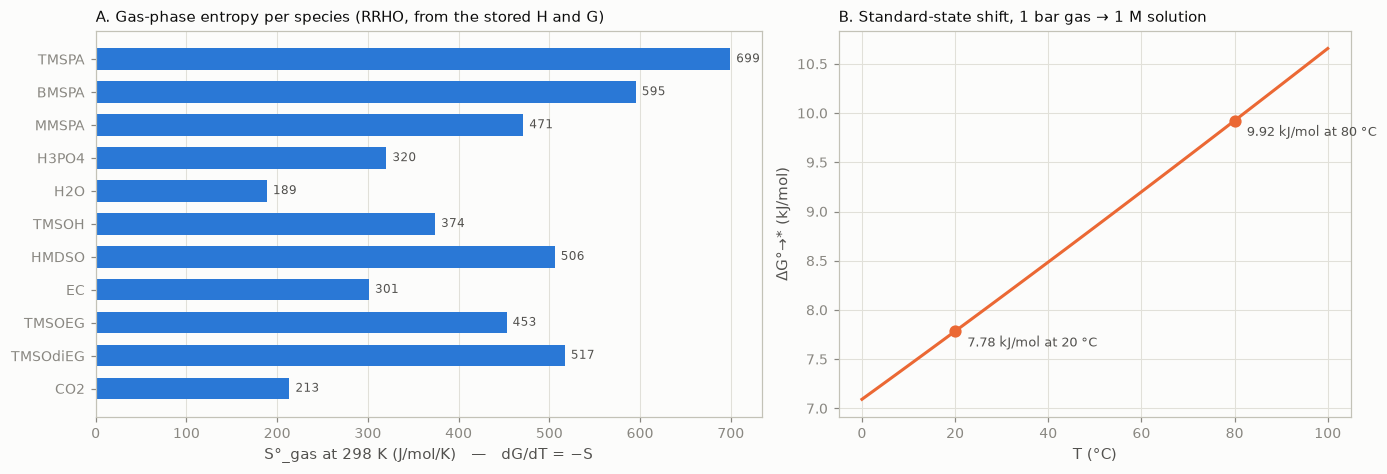

In [6]:
T_REF_K = 298.15

rows = []
for sp in NETWORK_SPECIES:
    sol = calculate_solution_gibbs(sp, T_REF_K, species_db=species_db, thermo_mode='wb97mv')
    rows.append({'species': sp,
                 'G_gas (eV)': species_db[sp]['G_gas_eV'],
                 'ΔE_solv (eV)': species_db[sp]['dE_solv_eV'],
                 'G_sol (eV)': sol['G_sol_eV']})               # G_gas + ΔE_solv ('wb97mv' omits the shift)
display(pd.DataFrame(rows).set_index('species').round(4))

# f(T): the standard-state shift, and the entropy that sets how each G would move with T
T_range_K = np.linspace(273.15, 373.15, 41)
shift_kJ_mol = [calculate_standard_state_shift(T) for T in T_range_K]
print(f'ΔG°→* = {calculate_standard_state_shift(293.15):.2f} kJ/mol at 20 °C, {calculate_standard_state_shift(353.15):.2f} kJ/mol at 80 °C')
thermo_plots.plot_species_temperature(species_table['S_gas (J/mol/K)'].to_dict(), T_range_K, shift_kJ_mol);

**Reading.** Heavy species have large entropies (TMSPA 699 J/mol/K). Its G would fall by about 42 kJ/mol between 20 and 80 °C, but reactants and products move together, so reaction energies change much less (Block 4). The standard-state shift grows from 7.8 to 9.9 kJ/mol over the window, and cancels in every reaction here.

---
## Block 3 — Reaction thermodynamics: driving forces and Wegscheider cycles

**What.** Each elementary step takes its free energy from the species, with ν > 0 for products:

$$\Delta G_\text{rxn} = \sum_i \nu_i\, G_{\text{sol},i}, \qquad K_\text{eq} = \exp\!\left(-\frac{\Delta G_\text{rxn}}{RT}\right)$$

The 9 steps form four families that later share a barrier: hydrolysis of the silyl phosphate (R1–R3), silanol condensation (R4), silyl transfer (R5–R7) and EC ring-opening by a silanol or glycol (R8–R9).

**Uncertainty.** σ(ΔΔE_solv) adds the standard errors of the mean MD energies of the species in quadrature. The pure-EC reference box is the same run for every species, so its term cancels in these 2 → 2 steps.

**Wegscheider consistency.** Silyl transfer equals hydrolysis followed by condensation: R5 = R1 + R4, R6 = R2 + R4, R7 = R3 + R4. Thermodynamics then requires ΔG₅ = ΔG₁ + ΔG₄, i.e. K₅ = K₁K₄. Building ΔG from species energies guarantees it. The kinetics keeps it only if every k_r follows from detailed balance (Block 5).

**Limitations.** No experimental reaction free energies exist for these steps. σ is the standard error of the mean MD energies (SLV-01).

,class,equation,ΔG_rxn (eV),ΔG_rxn (kcal/mol),±1σ solv (kcal/mol),sign resolved,K_eq
reaction,,,,,,,
R1,hydrolysis,TMSPA + H2O ⇌ BMSPA + TMSOH,-0.474,-10.94,6.03,yes,1.05e+08
R2,hydrolysis,BMSPA + H2O ⇌ MMSPA + TMSOH,-0.158,-3.64,5.67,no,4.69e+02
R3,hydrolysis,MMSPA + H2O ⇌ H3PO4 + TMSOH,-0.177,-4.09,5.57,no,9.99e+02
R4,condensation,2 TMSOH ⇌ HMDSO + H2O,+0.102,+2.34,7.76,no,1.92e-02
R5,transfer,TMSPA + TMSOH ⇌ BMSPA + HMDSO,-0.373,-8.60,5.78,yes,2.01e+06
R6,transfer,BMSPA + TMSOH ⇌ MMSPA + HMDSO,-0.056,-1.30,5.39,no,8.97e+00
R7,transfer,MMSPA + TMSOH ⇌ H3PO4 + HMDSO,-0.076,-1.75,5.29,no,1.91e+01
R8,solvent_attack,EC + TMSOH ⇌ TMSOEG + CO2,-0.047,-1.09,9.13,no,6.27e+00
R9,solvent_attack,EC + TMSOEG ⇌ TMSOdiEG + CO2,-0.467,-10.77,10.14,yes,7.89e+07


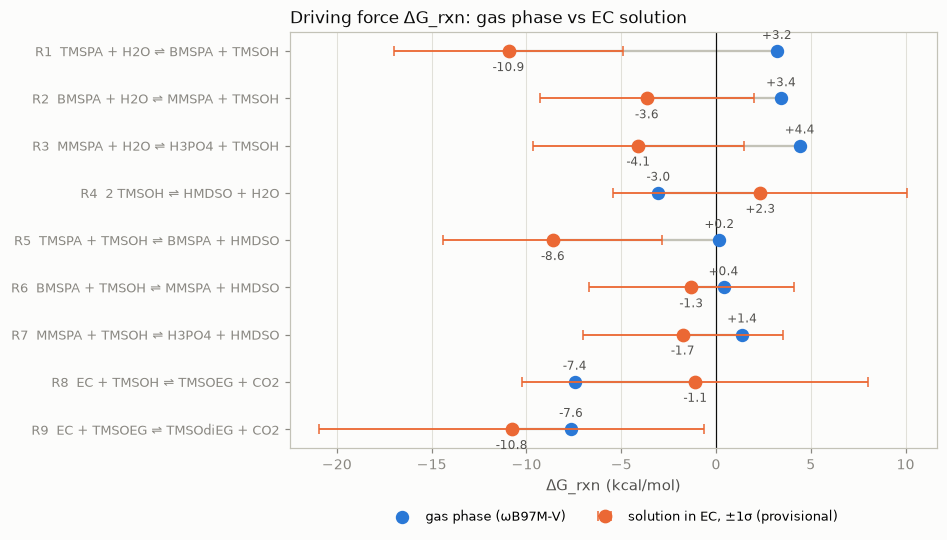

In [7]:
rows = []
for rxn_id, rxn in NETWORK.items():
    th = calculate_reaction_thermo(rxn_id, T_REF_K, network=NETWORK, species_db=species_db, thermo_mode='wb97mv')
    G_gas = {side: sum(nu * species_db[sp]['G_gas_eV'] for sp, nu in rxn[side].items()) for side in ('reactants', 'products')}
    rows.append({
        'reaction': rxn_id,
        'class': rxn['class'],
        'equation': format_equation(rxn),
        'dG_gas_eV': G_gas['products'] - G_gas['reactants'],                          # gas phase only
        'dG_rxn_eV': th['dG_rxn_eV'],                                                  # in EC (+ ΔΔE_solv)
        'dG_rxn_kJ_mol': th['dG_rxn_kJ_mol'],
        'sigma_solv_eV': calculate_solvation_sigma(rxn['reactants'], rxn['products']),  # shared EC term cancels
        'K_eq': th['K_eq'],
    })
thermo = pd.DataFrame(rows).set_index('reaction')
display(tables.format_thermo_table(thermo))
thermo_plots.plot_solvation_dumbbell(thermo);

Wegscheider cycle R1 + R4 − R5: Σ ν ΔG = +1.2e-10 kJ/mol
Wegscheider cycle R2 + R4 − R6: Σ ν ΔG = -8.1e-10 kJ/mol
Wegscheider cycle R3 + R4 − R7: Σ ν ΔG = +1.2e-10 kJ/mol


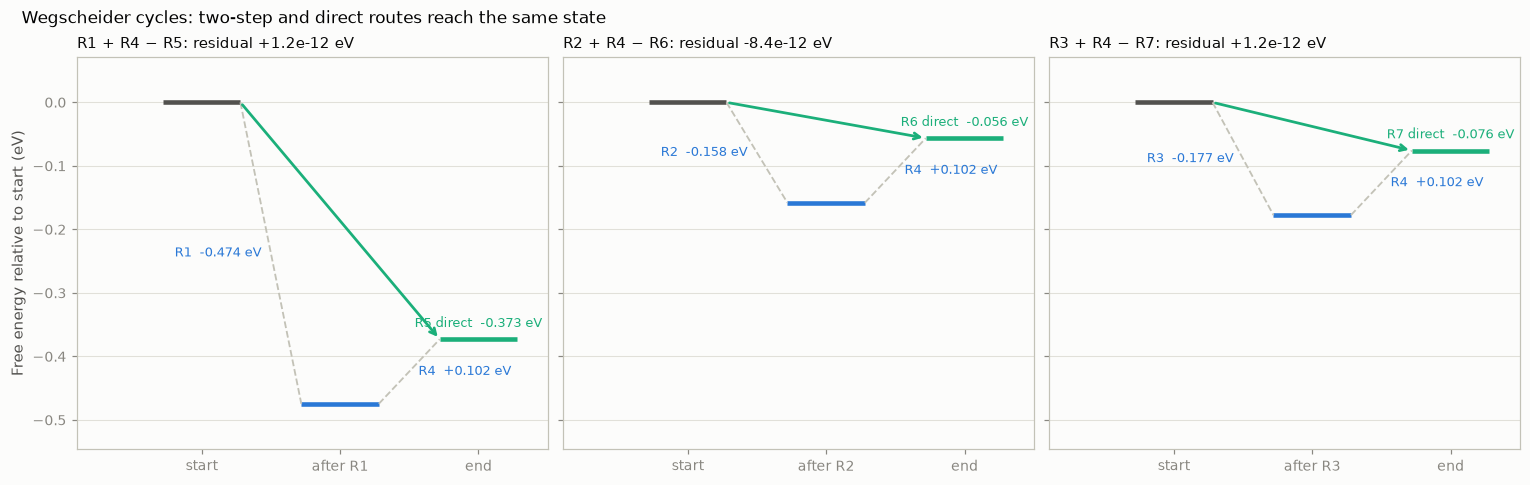

In [8]:
for cycle, residual in calculate_cycle_residuals(thermo['dG_rxn_kJ_mol'].to_dict()):
    print(f'Wegscheider cycle {cycle}: Σ ν ΔG = {residual:+.1e} kJ/mol')
thermo_plots.plot_wegscheider_cycles(thermo['dG_rxn_eV'].to_dict());

**Reading.**
- Solvation flips the sign of 7 of 9 steps: hydrolysis and silyl transfer become downhill, and condensation (R4) becomes uphill (K_eq ≈ 0.02).
- The standard error of the solvation term (0.23–0.44 eV) exceeds |ΔG_rxn| for R2–R4 and R6–R8, whose direction the data therefore cannot resolve. Only R1, R5 and R9 are clearly downhill.
- The three cycles close to rounding error: the direct transfer reaches exactly the state reached by hydrolysis plus condensation.

---
## Block 4 — Temperature dependence of the thermodynamics, f(T)

**What.** The protocol of notebook 02 runs from 20 to 80 °C. With the stored energies ΔG_rxn stays at its 298 K value, but K_eq still changes through 1/RT: a van 't Hoff plot with slope −ΔG/R. To estimate what a temperature-dependent ΔG would add, the RRHO entropy of the stored gas-phase data is kept:

$$\Delta G_\text{rxn}(T) \approx \Delta G_\text{rxn}(298\,\text{K}) - (T - 298\,\text{K})\,\Delta S_\text{rxn}, \qquad \Delta S_\text{rxn} = \sum_i \nu_i\,\frac{H_i - G_i}{298\,\text{K}}$$

**Limitations.** This is a sensitivity estimate, not a model mode:
- ΔH and ΔS are held at their 298 K values (no heat capacities).
- The entropy is that of the gas phase: solvation entropy is missing, and gas-phase translation overstates the freedom of a solute.

,ΔS_rxn (J/mol/K),ΔG at 20 °C (eV),ΔG at 80 °C (eV),change (eV),σ_solv (eV)
R1,81.212,-0.470,-0.521,-0.051,0.262
R2,61.334,-0.155,-0.193,-0.038,0.246
R3,34.345,-0.176,-0.197,-0.021,0.241
R4,-53.351,0.099,0.132,0.033,0.336
R5,27.862,-0.371,-0.389,-0.017,0.250
R6,7.984,-0.056,-0.061,-0.005,0.234
R7,-19.005,-0.077,-0.065,0.012,0.229
R8,-8.785,-0.048,-0.042,0.005,0.396
R9,-23.505,-0.468,-0.454,0.015,0.440


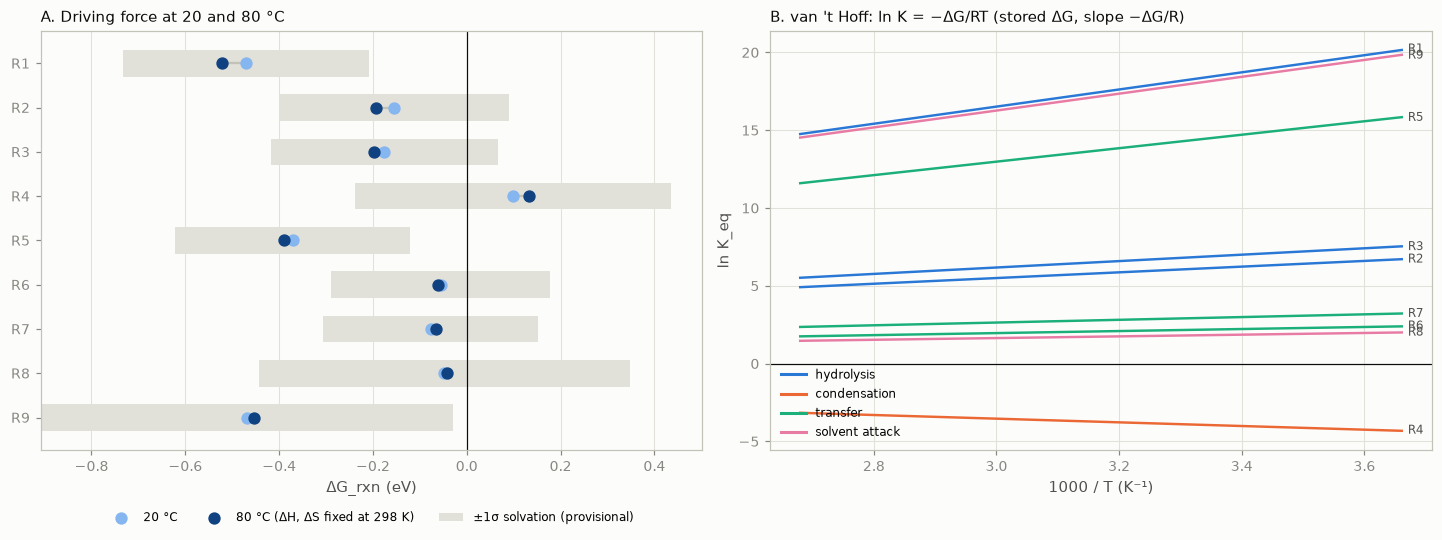

In [9]:
T_LOW_K, T_HIGH_K = 293.15, 353.15

dS_rxn = {}                                          # eV/K
for rxn_id, rxn in NETWORK.items():
    S = {sp: (species_db[sp]['H_gas_eV'] - species_db[sp]['G_gas_eV']) / T_STD_K for sp in NETWORK_SPECIES}
    dS_rxn[rxn_id] = sum(nu * S[sp] for sp, nu in rxn['products'].items()) - sum(nu * S[sp] for sp, nu in rxn['reactants'].items())
dS_rxn = pd.Series(dS_rxn)
dG_low = thermo['dG_rxn_eV'] - (T_LOW_K - T_STD_K) * dS_rxn
dG_high = thermo['dG_rxn_eV'] - (T_HIGH_K - T_STD_K) * dS_rxn

T_range_K = np.linspace(273.15, 373.15, 21)
lnK = pd.DataFrame({rxn_id: -thermo.loc[rxn_id, 'dG_rxn_eV'] / (KB_EV * T_range_K) for rxn_id in NETWORK}, index=T_range_K)

display(pd.DataFrame({'ΔS_rxn (J/mol/K)': dS_rxn * EV_TO_KJ_MOL * 1000, 'ΔG at 20 °C (eV)': dG_low,
                      'ΔG at 80 °C (eV)': dG_high, 'change (eV)': dG_high - dG_low,
                      'SE_solv (eV)': thermo['sigma_solv_eV']}).round(3))
thermo_plots.plot_temperature_dependence(dG_low, dG_high, thermo['sigma_solv_eV'], lnK, thermo['class'].to_dict());

**Reading.**
- Keeping the RRHO entropy moves ΔG_rxn by at most 0.05 eV between 20 and 80 °C: R1 and R2 become more downhill, R4 more uphill. That is five times smaller than the standard error of the solvation term, so a T-independent ΔG is a minor error here.
- In the van 't Hoff plot, K_eq of the downhill steps falls with temperature and that of R4 rises, but no step changes direction inside the window.

---
## Block 5 — Rate constants: barrier models and their assumptions

**What.** Transition-state theory (Eyring) gives each forward rate constant from an activation free energy; detailed balance gives the reverse one:

$$k_f = \frac{k_B T}{h}\exp\!\left(-\frac{\Delta G^\ddagger_f}{k_B T}\right), \qquad k_r = \frac{k_f}{K_\text{eq}}$$

Detailed balance keeps the Wegscheider cycles of Block 3 closed in the kinetics.

**Barriers.** No transition state has been computed, so ΔG‡ comes from a free-energy relation with one intrinsic barrier per family:
- **Capped BEP** (Peter's form): $\Delta G^\ddagger = \max(E_0,\; E_0 + \alpha\,\Delta G_\text{rxn})$, α = 0.5. Every downhill step gets exactly E0, and the barrier depends on the direction in which a reaction is written (Finding 15).
- **Marcus** (group transfer, λ = 4g): $\Delta G^\ddagger = g\,(1 + \Delta G_\text{rxn}/4g)^2$. Smooth and independent of the writing direction; Agmon–Levine and Blowers–Masel give nearly the same curve over this range.

**Assumptions under test.** The next cell defines the parameter sets, one intrinsic barrier (E0 or g) per family with the source of each value, and four models that combine them:
- the single E0 of Peter's protocol notebook;
- the family E0 of `tank_model.ipynb`;
- the same values under Marcus;
- the Level 1 set recalibrated on Gogoi 2024.

**Limitations.**
- One barrier per family, independent of T (ΔS‡ = 0).
- No acid catalysis of condensation, and no diffusion limit (available as an option).
- The hydrolysis barrier has no experimental anchor in any model.

In [10]:
# Intrinsic barrier per reaction family, in eV: E0 for the capped BEP, g for Marcus. α is the BEP slope.
E0_PETER = 1.15      # Broqvist, tmspa_hydrolysis_protocol.ipynb: spreads TMSPA consumption over 20-80 °C
E0_TANK = 0.80       # Broqvist, tank_model.ipynb: engineering placeholder, no experimental anchor

peter_parameters = {
    'default':        {'g_eV': E0_PETER, 'alpha': 0.50},   # one E0 for every family
}
family_parameters = {
    'hydrolysis':     {'g_eV': E0_TANK, 'alpha': 0.50},    # placeholder: no time-resolved data
    'condensation':   {'g_eV': E0_TANK, 'alpha': 0.50},    # placeholder: Gogoi 2024 needs ΔG‡(R4) ≥ 1.30 eV (Finding 16)
    'transfer':       {'g_eV': E0_TANK, 'alpha': 0.50},    # placeholder: Gogoi 2024 needs ΔG‡(R5) ≤ 0.925 eV
    'solvent_attack': {'g_eV': 1.30,    'alpha': 0.50},    # derived from the 80 °C protocol of Gogoi 2024 (Finding 8)
}
level1_parameters = {
    'hydrolysis':     {'shape': 'marcus', 'g_eV': 0.80},  # placeholder (Finding 18)
    'transfer':       {'shape': 'marcus', 'g_eV': 0.80},  # Gogoi 2024: g ≤ 1.02-1.10 eV (TMSPA + TMSOH react at RT)
    'condensation':   {'shape': 'marcus', 'g_eV': 1.30},  # Gogoi 2024: g ≥ 1.25 eV (no TMSOTMS from TMSOH alone)
    'solvent_attack': {'shape': 'marcus', 'g_eV': 1.32},  # Gogoi 2024: g = 1.27-1.38 eV (EC opens at 80 °C, not at RT)
}

# Candidate models: name, label, barrier relation, parameter set, status. All use the stored ωB97M-V G.
models = {
    'peter_reference': ModelSpec('peter_reference', 'capped BEP, one E0', 'bep_eyring', peter_parameters, status='reference'),
    'family_bep':      ModelSpec('family_bep', 'capped BEP, E0 per family', 'bep_eyring', family_parameters, status='sensitivity'),
    'family_marcus':   ModelSpec('family_marcus', 'Marcus, g per family', 'marcus_eyring', family_parameters, status='sensitivity'),
    'level1':          ModelSpec('level1', 'Marcus, g recalibrated on Gogoi 2024', 'level1', level1_parameters, status='provisional'),
}
tables.format_family_barriers(tabulate_family_barriers(models.values()), barrier_windows)

,reactions,peter_reference,family_bep,family_marcus,level1,experimental window (Gogoi 2024)
hydrolysis,"R1, R2, R3",1.15,0.80,0.80,0.80,none (no time-resolved data)
condensation,R4,1.15,0.80,0.80,1.30,ΔG‡(R4) ≥ 1.3 eV at 80 °C (assumed)
transfer,"R5, R6, R7",1.15,0.80,0.80,0.80,ΔG‡(R5) ≤ 0.925 eV at 25 °C (assumed)
solvent_attack,"R8, R9",1.15,1.30,1.30,1.32,ΔG‡(R8) 1.25–1.36 eV at 80 °C (derived)


max |k_f/k_r − K_eq| / K_eq = 0.0e+00


ΔG‡_f (eV)                                      log10 k_f at 20 °C  \
model    family_bep family_marcus level1 peter_reference         family_bep   
reaction                                                                      
R1             0.80          0.58   0.58            1.15              -0.97   
R2             0.80          0.72   0.72            1.15              -0.97   
R3             0.80          0.71   0.71            1.15              -0.97   
R4             0.85          0.85   1.35            1.20              -1.84   
R5             0.80          0.62   0.62            1.15              -0.97   
R6             0.80          0.77   0.77            1.15              -0.97   
R7             0.80          0.76   0.76            1.15              -0.97   
R8             1.30          1.28   1.30            1.15              -9.56   
R9             1.30          1.08   1.10            1.15              -9.56   

                                               
model    family_marcus level1 peter_reference  
reaction                                       
R1                2.81   2.81           -6.98  
R2                0.36   0.36           -6.98  
R3                0.52   0.52           -6.98  
R4               -1.85 -10.45           -7.86  
R5                2.05   2.05           -6.98  
R6               -0.49  -0.49           -6.98  
R7               -0.32  -0.32           -6.98  
R8               -9.16  -9.50           -6.98  
R9               -5.73  -6.07           -6.98

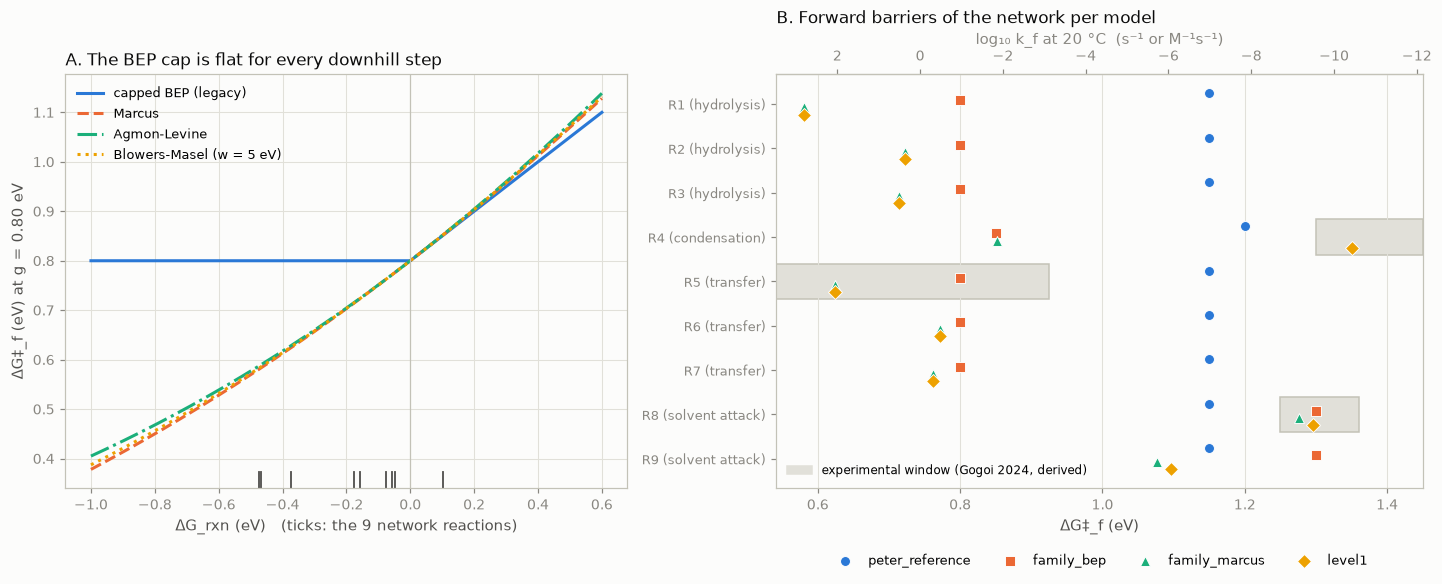

In [11]:
T_COMPARE_K = 293.15

rows = []
for name, model in models.items():
    for rxn_id in NETWORK:
        r = calculate_rate_constants(rxn_id, T_COMPARE_K, kinetic_model=model.kinetic_model,
                                     family_params=model.family_params, network=NETWORK,
                                     species_db=species_db, thermo_mode=model.thermo_mode)
        rows.append({'model': name, 'reaction': rxn_id, 'class': r['class'], 'dG_rxn_eV': r['dG_rxn_eV'],
                     'dG_barrier_f_eV': r['dG_barrier_f_eV'], 'k_f': r['k_f'], 'k_r': r['k_r'], 'K_eq': r['K_eq']})
rates = pd.DataFrame(rows).set_index(['model', 'reaction'])

# Detailed balance: k_f / k_r must equal K_eq for every model and reaction
print(f"max |k_f/k_r − K_eq| / K_eq = {((rates['k_f'] / rates['k_r'] - rates['K_eq']).abs() / rates['K_eq']).max():.1e}")
display(pd.concat({'ΔG‡_f (eV)': rates['dG_barrier_f_eV'].unstack('model'),
                   'log10 k_f at 20 °C': np.log10(rates['k_f']).unstack('model')}, axis=1).round(2))
rate_plots.plot_barrier_comparison({name: rates.loc[name] for name in models}, T_COMPARE_K, constraints=barrier_windows);

**Reading.**
- (A) Under the capped BEP every downhill step gets ΔG‡ = E0: α only acts on uphill R4, and ΔG_rxn does not rank the rates. The smooth shapes nearly coincide, so the barrier value matters far more than the shape.
- (B) The models disagree by up to 0.6 eV on the same reaction, about 10 decades in k_f at 20 °C.
- Against the experimental windows (shaded), `peter_reference` puts transfer (R5) too high and solvent attack (R8) too low: one E0 cannot serve both families. `family_bep` and `family_marcus` put condensation (R4) far below its bound. `level1` meets all three windows, having been calibrated on them.

---
## Block 6 — Models against experiment, and model selection

**What.** Each control experiment of Gogoi et al. is re-simulated with every model, using the batch reactor of Block 8 at the experiment's composition, temperature and time (EC buffered at 7.1 M; DEC is inert). The predicted observable is then compared with the window the observation implies:
- **E1:** 0.45 M TMSOH in EC, 1 week at room temperature. No ring-opening (< 2 %).
- **E2:** the same mixture, 8 h at 80 °C. TMS-EG clearly formed (5–90 % of the TMSOH).
- **E3:** the same mixture, 8 h at 80 °C. TMSOTMS (HMDSO) only at impurity level (< 5 % of the Si).
- **E4:** 0.15 M TMSPA + 0.18 M TMSOH at room temperature. Both consumed (≥ 95 %, time assumed 24 h).

**Limitations.**
- The windows are derived, and those of E3 and E4 rest on an assumed detection limit or time.
- The paper heated its samples stepwise; each check uses the single hold its derivation refers to.

,conditions,observable,observed window,peter_reference,family_bep,family_marcus,level1
E1,"TMSOH in EC, RT, 1 week",TMSOH ring-opened into TMSOEG + TMSOdiEG (fraction),≤ 0.02 (derived),0.617 ✗,0.00221 ✓,0.00551 ✓,0.00323 ✓
E2,"TMSOH in EC, 8 h at 80 °C",TMSOH ring-opened into TMSOEG + TMSOdiEG (fraction),≥ 0.05 and ≤ 0.9 (derived),0.989 ✗,0.264 ✓,0.485 ✓,0.375 ✓
E3,"TMSOH in EC, 8 h at 80 °C",Si of TMSOH ending in HMDSO (fraction),≤ 0.05 (assumed),0.0106 ✓,0.201 ✗,0.141 ✗,0.00636 ✓
E4,"TMSPA + TMSOH in EC, RT, 24 h",TMSPA converted (fraction),≥ 0.95 (assumed),0.00327 ✗,1 ✓,1 ✓,1 ✓


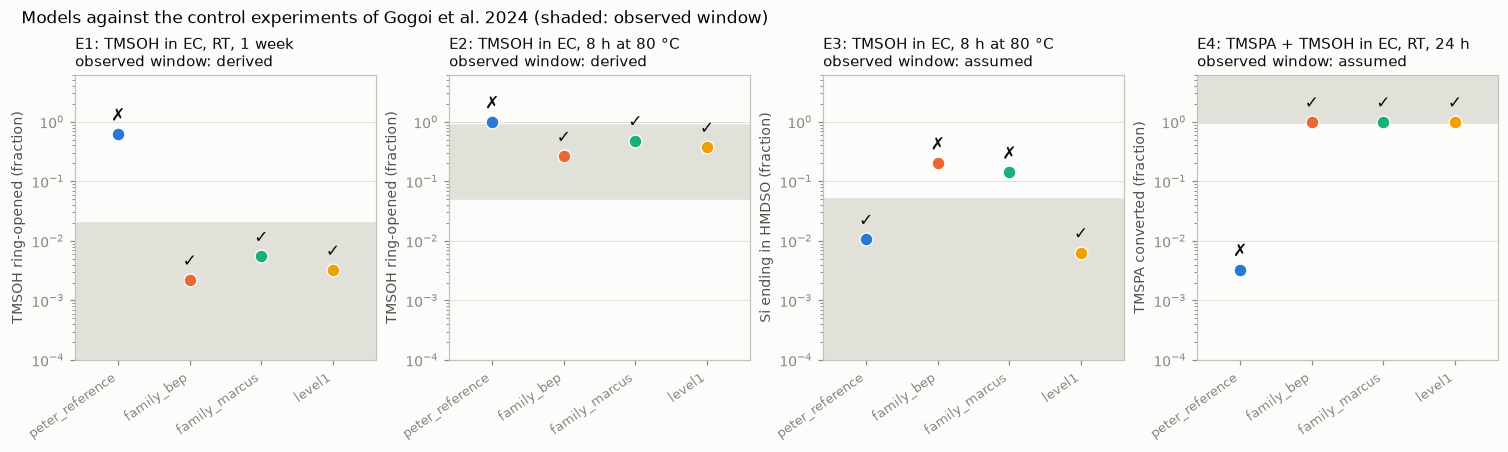

In [12]:
rows = []
for exp_id, exp in controls.iterrows():
    c0_M = dict.fromkeys(NETWORK_SPECIES, 0.0)
    c0_M.update(exp['c0_M'])
    label, observable = OBSERVABLES[exp['observable']]      # e.g. (TMSOEG + TMSOdiEG) / TMSOH0
    for name, model in models.items():
        run = simulate_batch_reactor(c0_M, T_K=exp['T_K'], t_end_s=exp['t_s'], model=model, species_db=species_db,
                                     n_points=40, t_start_s=1.0)
        value = observable(run['C_M'][:, -1], run['idx'], c0_M)
        rows.append({'experiment': exp_id, 'label': exp['label'], 'observable': exp['observable'],
                     'observable_label': label, 'model': name, 'predicted': value,
                     'low': exp['low'], 'high': exp['high'], 'status': exp['status'],
                     'consistent': (np.isnan(exp['low']) or value >= exp['low']) and (np.isnan(exp['high']) or value <= exp['high'])})
checks = pd.DataFrame(rows)
display(tables.format_control_checks(checks))
reactor_plots.plot_control_experiments(checks);

**Reading.**
- `peter_reference` fails 3 of 4 controls. It opens EC at room temperature (62 % of the TMSOH in a week, where none is seen), and its silyl transfer is about 300-fold too slow. It passes E3 only because its fast ring-opening removes TMSOH before it can condense.
- `family_bep` and `family_marcus` fail E3: their 0.80 eV condensation turns 14–20 % of the TMSOH into HMDSO.
- `level1` passes all four, but its hydrolysis barrier (0.80 eV) is unanchored, and in notebook 02 it consumes TMSPA before the first acquisition.
- No model satisfies both the controls and a gradual TMSPA consumption. A time-resolved TMSPA decay (the hydrolysis barrier) is the missing measurement.

### Model selection

Set `SELECTED` to any key of `models`; the following blocks use it. The default `peter_reference` reproduces Peter's protocol notebook; `level1` is the model consistent with the controls.

In [13]:
SELECTED = 'peter_reference'

model = models[SELECTED]
passed = checks.loc[(checks['model'] == SELECTED) & checks['consistent'], 'experiment'].tolist()
print(f'{SELECTED}: {model.label} [{model.status}], barrier relation {model.kinetic_model}')
print(f'consistent with {len(passed)} of {len(controls)} control experiments: {passed}')
pd.DataFrame(model.family_params).T

peter_reference: capped BEP, one E0 [reference], barrier relation bep_eyring
consistent with 1 of 4 control experiments: ['E3']


,g_eV,alpha
default,1.15,0.5


---
## Block 7 — Temperature dependence of the rates, k(T)

**What.** The Eyring expression already has the modified-Arrhenius form

$$k(T) = A\left(\frac{T}{T_0}\right)^{\beta}\exp\!\left(-\frac{E_a}{RT}\right), \qquad A = \frac{k_B T_0}{h},\;\; \beta = 1,\;\; E_a = \Delta G^\ddagger$$

so a fit over 0–100 °C returns the model's own barrier with R² = 1. It is a consistency check, not a validation. What matters for the protocol is the acceleration between 20 and 80 °C, about $(T_2/T_1)\exp[\Delta G^\ddagger (1/k_BT_1 - 1/k_BT_2)]$, which reaches ~10³ for a 1.15 eV barrier. The experimental windows are drawn at their own temperature.

**Limitations.** Barriers do not depend on T (ΔS‡ = 0) and ΔG_rxn is fixed, so the only curvature comes from the T prefactor.

,A,β,Ea (eV),R²,k_f 20 °C,k_f 80 °C,k80 / k20
reaction,,,,,,,
R1,6.21e+12,1,1.15,1,1.04e-07,0.000285,2.75e+03
R2,6.21e+12,1,1.15,1,1.04e-07,0.000285,2.75e+03
R3,6.21e+12,1,1.15,1,1.04e-07,0.000285,2.75e+03
R4,6.21e+12,1,1.2,1,1.39e-08,5.37e-05,3.88e+03
R5,6.21e+12,1,1.15,1,1.04e-07,0.000285,2.75e+03
R6,6.21e+12,1,1.15,1,1.04e-07,0.000285,2.75e+03
R7,6.21e+12,1,1.15,1,1.04e-07,0.000285,2.75e+03
R8,6.21e+12,1,1.15,1,1.04e-07,0.000285,2.75e+03
R9,6.21e+12,1,1.15,1,1.04e-07,0.000285,2.75e+03


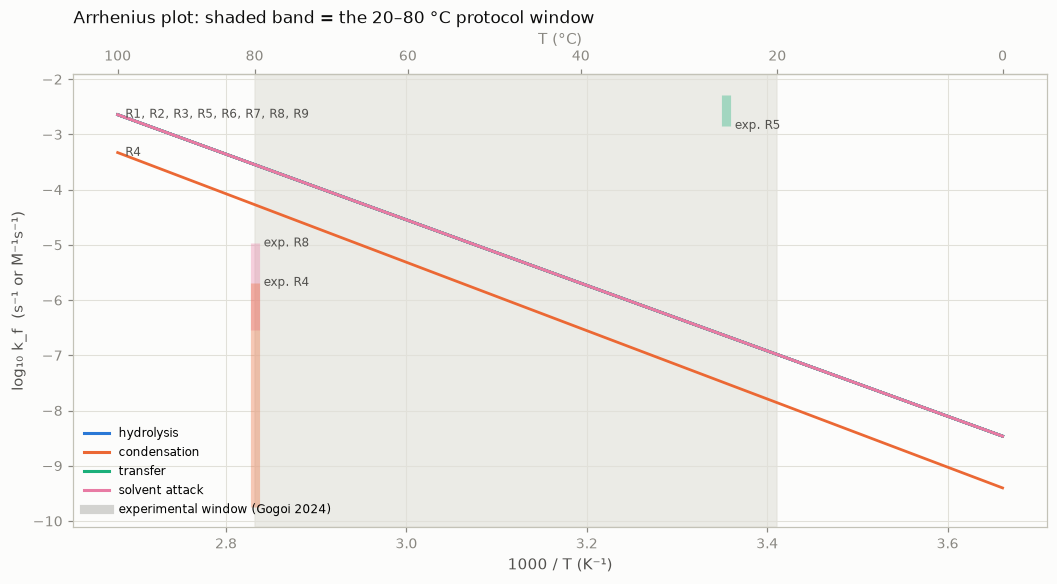

In [14]:
T_grid_K = np.linspace(273.15, 373.15, 21)
rate_options = dict(kinetic_model=model.kinetic_model, family_params=model.family_params, species_db=species_db)

k_f = pd.DataFrame({rxn_id: [calculate_rate_constants(rxn_id, T, **rate_options)['k_f'] for T in T_grid_K]
                    for rxn_id in NETWORK}, index=T_grid_K)

rows = []
for rxn_id in NETWORK:
    fit = fit_modified_arrhenius(rxn_id, T_grid_K, **rate_options)
    k_20 = calculate_rate_constants(rxn_id, T_LOW_K, **rate_options)['k_f']
    k_80 = calculate_rate_constants(rxn_id, T_HIGH_K, **rate_options)['k_f']
    rows.append({'reaction': rxn_id, 'A': fit['A'], 'β': fit['beta'], 'Ea (eV)': fit['Ea_eV'], 'R²': fit['R2'],
                 'k_f 20 °C': k_20, 'k_f 80 °C': k_80, 'k80 / k20': k_80 / k_20})
display(pd.DataFrame(rows).set_index('reaction').map(lambda v: f'{v:.3g}'))
rate_plots.plot_arrhenius(k_f, thermo['class'].to_dict(), windows=barrier_windows);

**Reading** (`peter_reference`). All nine reactions accelerate by about 2.8·10³ (R4 by 3.9·10³) between 20 and 80 °C, which is what lets a stepwise temperature program spread TMSPA consumption over several holds. At their own temperatures, the experimental windows lie below its R8 line and above its R5 line.

---
## Block 8 — Isothermal batch reactor ('tank')

**What.** The mass balance of every species in a closed, well-mixed, isothermal reactor:

$$\frac{dC_i}{dt} = \sum_j \nu_{ij}\, r_j, \qquad r_j = k_{f,j}\prod_{\text{reactants}} C_k^{\nu_k} - k_{r,j}\prod_{\text{products}} C_l^{\nu_l}$$

This is mass action with concentrations in M standing in for activities.

**Method.** The rate constants span more than ten decades, so the system is stiff. It is solved with the implicit Radau IIA method (order 5) and an analytic Jacobian. EC is the solvent and stays at its initial concentration (buffered). Si and P atoms must be conserved, which checks the stoichiometry.

**Scenario.** A sealed electrolyte at 25 °C for 10 years, with 50 mM TMSPA, 20 mM water (≈ 280 ppm at 1.3 g/mL) and 4.5 M EC, run with every model.

**Limitations.** Ideal dilute solution (no activity coefficients); no Li⁺, LiPF₆ or HF chemistry; CO₂ stays dissolved.

peter_reference  The solver successfully reached the end of the integration interval.  Si/P conserved: {'Si': True, 'P': True}
family_bep       The solver successfully reached the end of the integration interval.  Si/P conserved: {'Si': True, 'P': True}
family_marcus    The solver successfully reached the end of the integration interval.  Si/P conserved: {'Si': True, 'P': True}
level1           The solver successfully reached the end of the integration interval.  Si/P conserved: {'Si': True, 'P': True}


,t½ TMSPA (h),t 90 % H2O used (h),peak TMSOH (mM),final CO2 (mM),final HMDSO (mM)
peter_reference,not reached,5.63e+04,0.209,38.7,0.0722
family_bep,0.0763,0.0476,10.2,8.37e-05,20
family_marcus,2.67e-05,1.89e-05,13.7,0.000186,20
level1,2.67e-05,1.89e-05,13.7,8.54e-05,20


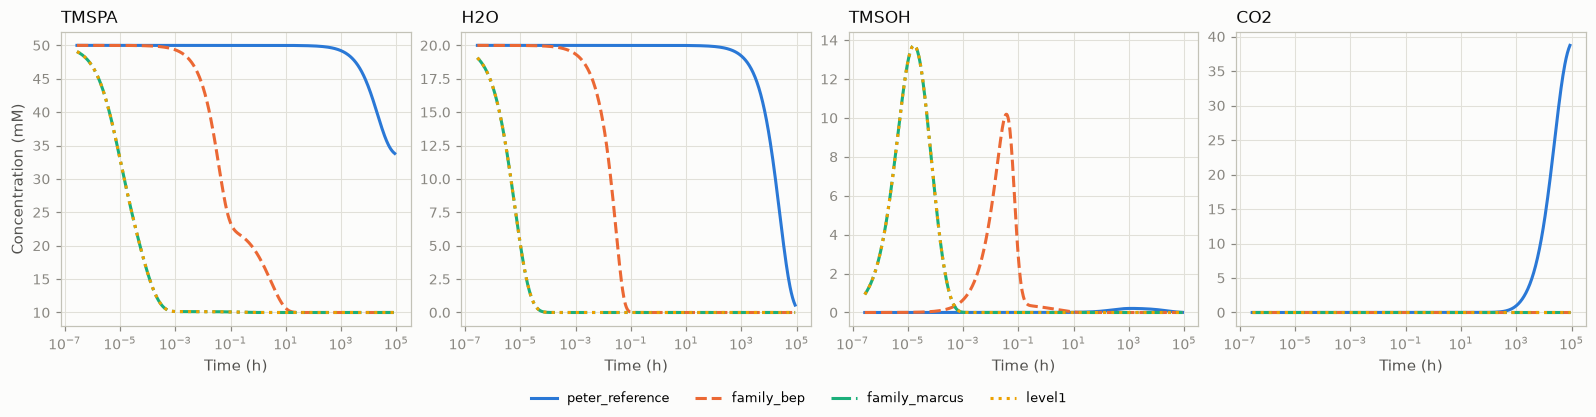

In [15]:
C0_M = {                   # initial concentrations (mol/L)
    'TMSPA':    0.050,     # scavenger
    'BMSPA':    0.0,
    'MMSPA':    0.0,
    'H3PO4':    0.0,
    'H2O':      0.020,     # trace water, ≈ 280 ppm
    'TMSOH':    0.0,
    'HMDSO':    0.0,
    'EC':       4.5,       # solvent, buffered
    'TMSOEG':   0.0,
    'TMSOdiEG': 0.0,
    'CO2':      0.0,
}
T_TANK_K = 298.15
T_END_S = 10 * 365.25 * 24 * 3600      # 10 years

tank = {}
for name, m in models.items():
    tank[name] = simulate_batch_reactor(C0_M, T_K=T_TANK_K, t_end_s=T_END_S, model=m, species_db=species_db,
                                        buffered_species=('EC',), method='Radau', rtol=1e-8, atol=1e-12)
    print(f"{name:16s} {tank[name]['message']}  Si/P conserved: {tank[name]['elements_conserved']}")

scorecard = pd.DataFrame({name: {
    't½ TMSPA (h)':       find_crossing_time(run['t_h'], run['C_mM'][run['idx']['TMSPA']], 0.5 * C0_M['TMSPA'] * 1000),
    't 90 % H2O used (h)': find_crossing_time(run['t_h'], run['C_mM'][run['idx']['H2O']], 0.1 * C0_M['H2O'] * 1000),
    'peak TMSOH (mM)':    run['C_mM'][run['idx']['TMSOH']].max(),
    'final CO2 (mM)':     run['C_mM'][run['idx']['CO2'], -1],
    'final HMDSO (mM)':   run['C_mM'][run['idx']['HMDSO'], -1],
} for name, run in tank.items()}).T
display(tables.format_scorecard(scorecard))
reactor_plots.plot_model_overlay(tank, ['TMSPA', 'H2O', 'TMSOH', 'CO2'], log_time=True);

**Reading.**
- The same thermodynamics gives water-scavenging times from under 0.1 s (Marcus-type models) through about 3 min (`family_bep`) to about 6 years (`peter_reference`).
- With fast hydrolysis and transfer, TMSOH transfers its silyl group and ends up in HMDSO (20 mM). Under `peter_reference` all barriers are equal, so EC (4.5 M) outcompetes TMSPA (50 mM) for TMSOH: it opens EC instead (≈ 39 mM CO₂) and TMSPA never falls to half. This is the behaviour that fails control E1.
- `family_marcus` and `level1` coincide here: they share g = 0.80 eV for hydrolysis and transfer, the steps that dominate at 25 °C.

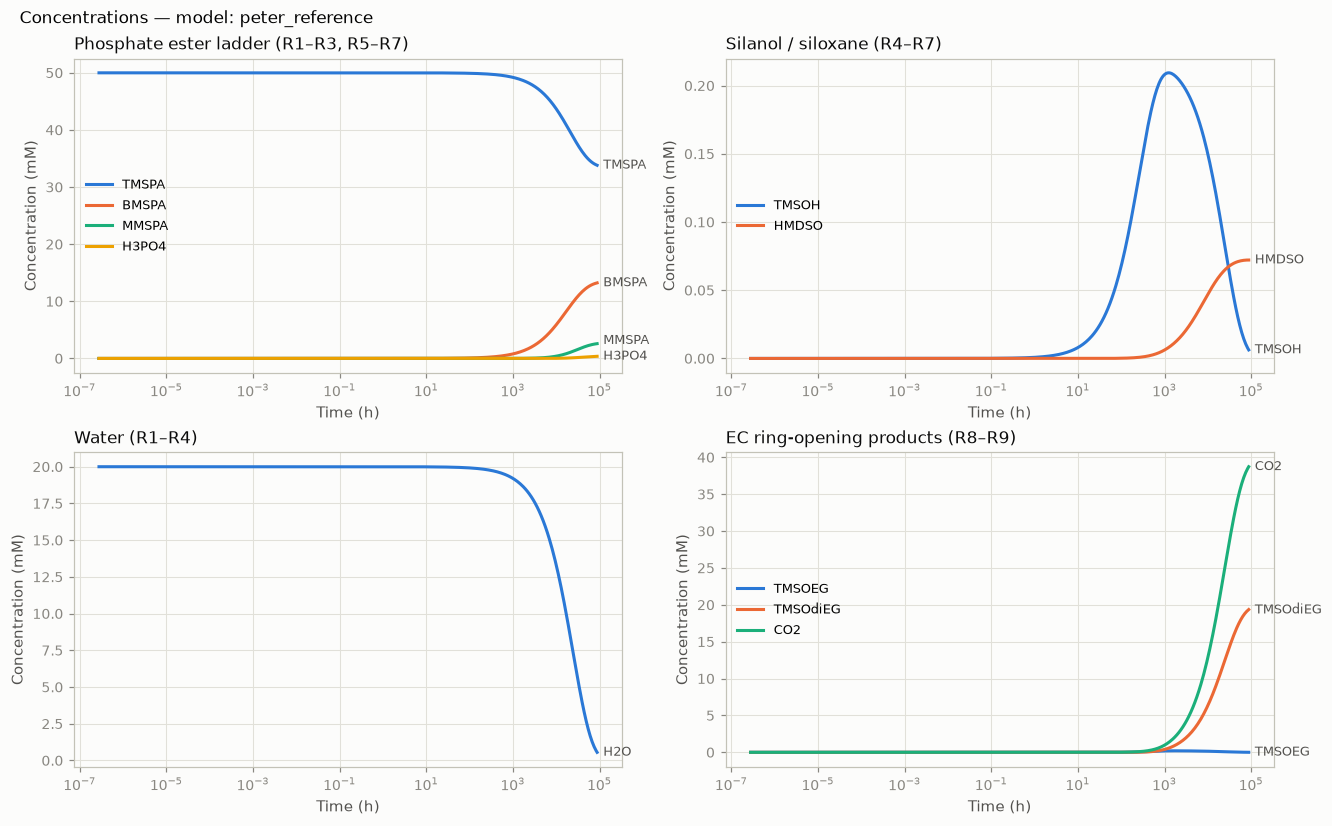

In [16]:
sim = tank[SELECTED]
reactor_plots.plot_concentration_panels(sim, log_time=True);

**Reading** (`peter_reference`). Little changes in the first ~10³ h (six weeks). Over the following years water is consumed through R1 and BMSPA accumulates. TMSOH stays below 0.2 mM because EC ring-opening (R8) takes it as fast as it forms, and chain growth (R9) releases a second CO₂ (CO₂ ≈ 2 × TMSOdiEG).

---
## Block 9 — Sensitivity: how the barrier sets the time scale

**What.** Under the capped BEP every downhill step runs at $k = (k_BT/h)\,e^{-E_0/k_BT}$, so every time scale grows as $e^{E_0/k_BT}$: each +0.1 eV slows the chemistry about 49-fold at 25 °C. The tank of Block 8 is rerun with one global E0 from 0.80 to 1.20 eV, which places the placeholder (0.80 eV) and Peter's value (1.15 eV) on the same axis.

**Limitation.** One barrier for all families: this isolates the time-scale effect, not the product distribution.

,0.80,0.85,0.90,0.95,1.00,1.05,1.10,1.15,1.20
t 90 % H2O used (h),0.0683,0.478,3.35,23.4,164,1.15e+03,8.04e+03,5.63e+04,3.94e+05


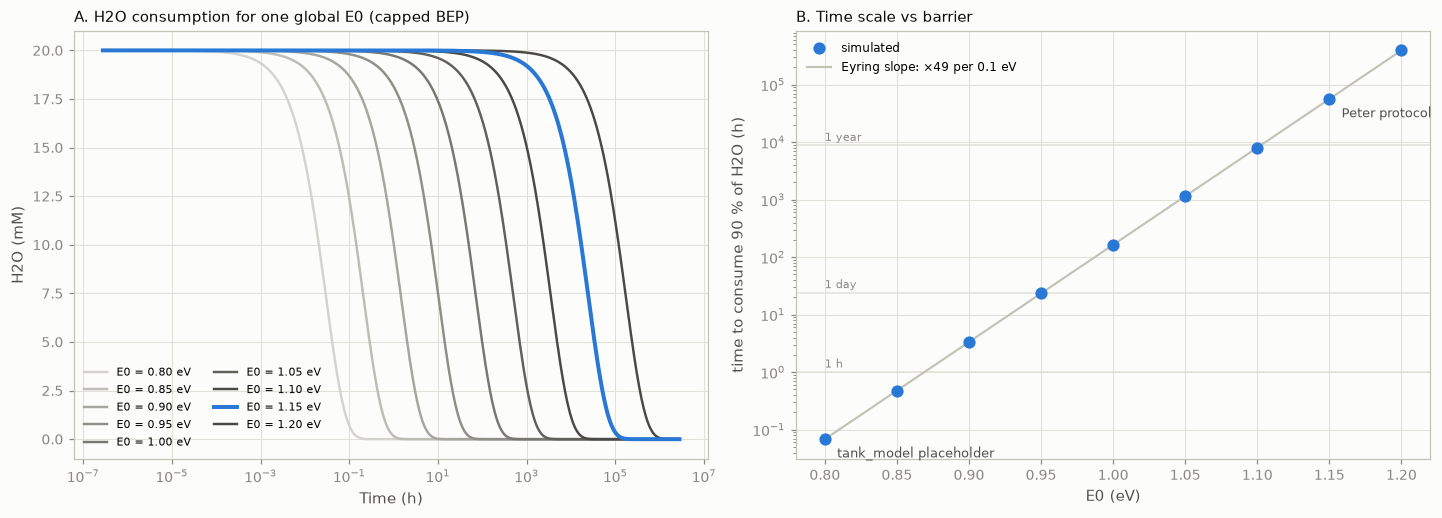

In [17]:
E0_sweep = [0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20]

sweep, t90_h = {}, {}
for E0 in E0_sweep:
    m = ModelSpec(f'E0 = {E0:.2f}', 'one global E0', 'bep_eyring', {'default': {'g_eV': E0, 'alpha': 0.50}})
    run = simulate_batch_reactor(C0_M, T_K=T_TANK_K, t_end_s=1e10, model=m, species_db=species_db)
    sweep[E0] = run
    t90_h[E0] = find_crossing_time(run['t_h'], run['C_mM'][run['idx']['H2O']], 0.1 * C0_M['H2O'] * 1000)

display(pd.Series(t90_h, name='t 90 % H2O used (h)').to_frame().T.map(lambda v: f'{v:.3g}'))
reactor_plots.plot_barrier_sensitivity(sweep, t90_h, species='H2O', highlight=E0_PETER,
                                       marks={E0_TANK: 'tank_model placeholder', E0_PETER: 'Peter protocol'});

**Reading.** Consuming 90 % of the water takes 4 min at 0.80 eV and 6.4 years at 1.15 eV: seven decades for 0.35 eV, exactly the Eyring slope. A 0.1 eV error in the barrier is a factor of 50 in any predicted lifetime, far more than any thermodynamic uncertainty of Blocks 3–4.

---
## Block 10 — Virtual ²⁹Si NMR and the measured shifts

**What.** Concentrations are turned into the spectrum an NMR experiment would record:
- **Shifts:** $\delta_i = \sigma_\text{ref} - \sigma_i$ from the DFT shieldings, referenced to TMS for ²⁹Si and to H₃PO₄ for ³¹P. Chemically equivalent atoms are found from the bond graph (colour refinement) and averaged, since a single static geometry makes them differ slightly.
- **Intensity:** each site adds a Lorentzian of area ∝ (number of atoms) × concentration, $I(\delta,t) = \sum_i n_i C_i(t)\,\frac{(\Gamma/2)^2}{(\delta-\delta_i)^2 + (\Gamma/2)^2}$ with FWHM Γ = 0.4 ppm. Labile OH protons are exchange-averaged into one peak, and the solvent is not summed.

**Limitations.** These are gas-phase shifts of single conformers. They locate peaks but carry no kinetic information.

,nucleus,species,computed (ppm),measured (ppm),computed − measured (ppm)
0,P,TMSPA,-22.02,-24.60,2.58
1,P,BMSPA,-14.29,-14.55,0.26
2,P,MMSPA,-7.04,-7.20,0.16
3,P,H3PO4,0.00,-0.30,0.30
4,Si,TMSPA,27.60,25.00,2.60
5,Si,BMSPA,28.47,25.00,3.47
6,Si,MMSPA,30.96,25.00,5.96
7,Si,TMSOH,21.00,15.00,6.00
8,Si,HMDSO,12.35,7.00,5.35


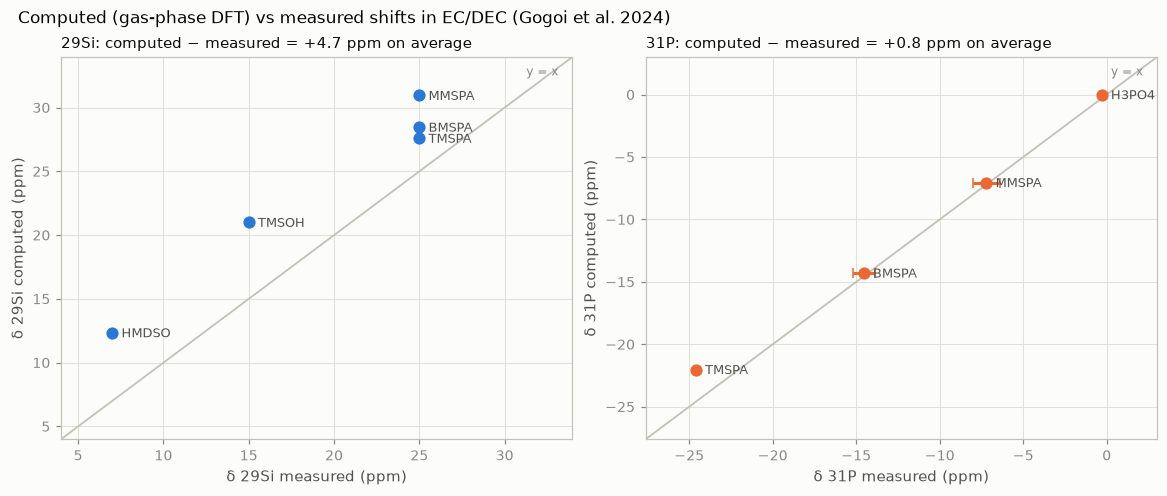

In [18]:
nmr_catalog = build_nmr_catalog()          # {nucleus: {species: [(δ ppm, number of atoms, labile)]}}

rows = []
for _, m in measured_shifts.iterrows():
    computed = [d for d, _, labile in nmr_catalog[m['nucleus']].get(m['species'], []) if not labile][0]
    rows.append({'nucleus': m['nucleus'], 'species': m['species'], 'computed (ppm)': computed,
                 'measured (ppm)': m['mid_ppm'], 'computed − measured (ppm)': computed - m['mid_ppm']})
display(pd.DataFrame(rows).round(2))
nmr_plots.plot_shift_parity(nmr_catalog, measured_shifts);

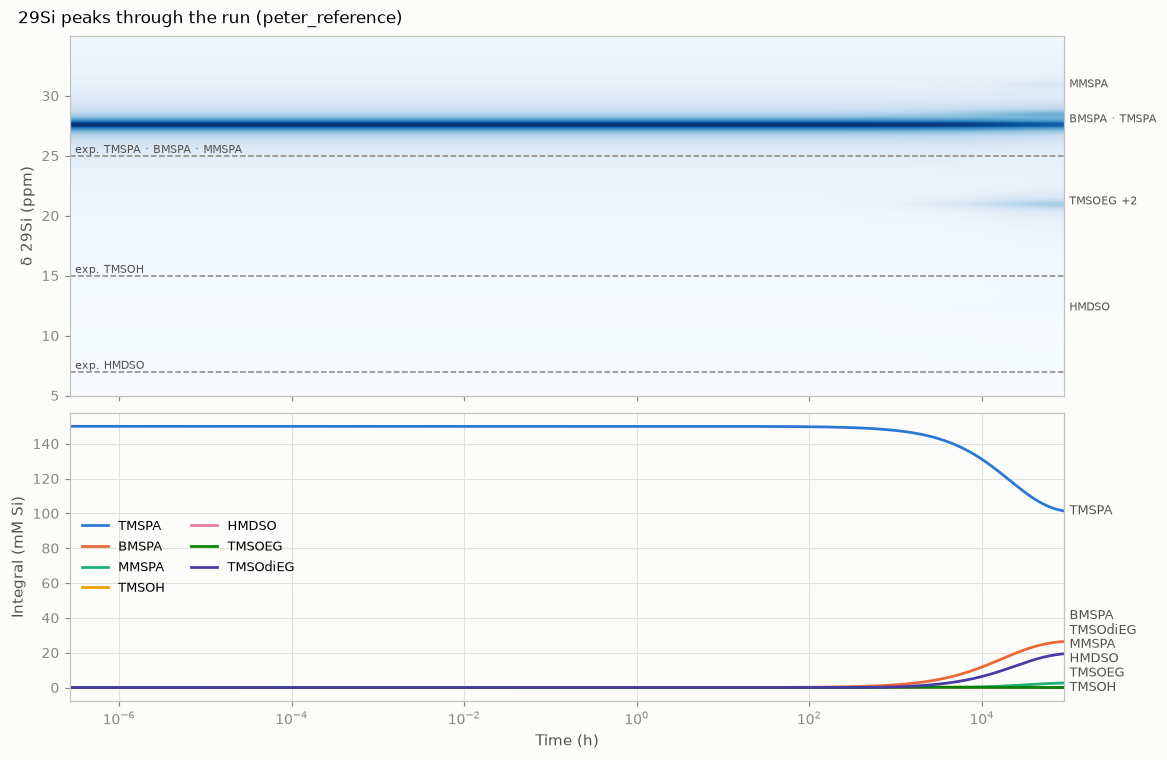

In [19]:
nmr_plots.plot_peak_tracking(sim, 'Si', nmr_catalog, log_time=True, experimental=measured_shifts);

**Reading.**
- ³¹P agrees with experiment within 2.6 ppm, which is enough to assign the phosphate ladder. ²⁹Si comes out 3–6 ppm too high (dashed lines: measured).
- Computed TMSPA, BMSPA and MMSPA lie within 3.4 ppm and overlap, as the measured xMSPA band at ≈ 25 ppm does. TMSOH and the glycol adducts sit together near 21 ppm, and only HMDSO is isolated.
- ²⁹Si alone cannot follow the phosphate ladder; ³¹P can (notebook 02).

---
## Block 11 — Export

Writes the inputs, tables and trajectories of this notebook to `notebooks/results/01/` as CSV (ignored by git).

In [20]:
RESULTS = REPO / 'notebooks' / 'results' / '01'
RESULTS.mkdir(parents=True, exist_ok=True)

exports = {
    'snapshot_inputs.csv':      raw_inputs,
    'species_table.csv':        species_table,
    'reaction_thermo_298K.csv': thermo,
    'family_barriers_eV.csv':   tabulate_family_barriers(models.values()),
    'rate_constants_20C.csv':   rates,
    'control_experiments.csv':  checks,
    'tank_scorecard.csv':       scorecard,
    'E0_sensitivity.csv':       pd.Series(t90_h, name='t90_H2O_h'),
    f'tank_trajectory_{SELECTED}.csv': tabulate_trajectory(sim),
}
for filename, frame in exports.items():
    frame.to_csv(RESULTS / filename)
    print(f'{RESULTS.relative_to(REPO) / filename}: {len(frame)} rows')

notebooks/results/01/snapshot_inputs.csv: 11 rows
notebooks/results/01/species_table.csv: 11 rows
notebooks/results/01/reaction_thermo_298K.csv: 9 rows
notebooks/results/01/family_barriers_eV.csv: 4 rows
notebooks/results/01/rate_constants_20C.csv: 36 rows
notebooks/results/01/control_experiments.csv: 16 rows
notebooks/results/01/tank_scorecard.csv: 4 rows
notebooks/results/01/E0_sensitivity.csv: 9 rows
notebooks/results/01/tank_trajectory_peter_reference.csv: 500 rows
